## Цель

Сравнить эффективность LLM разного размера для коррекции ошибок ASR.

### ASR модели

| Модель | Параметры | Тип | Языки |
|--------|-----------|-----|-------|
| Whisper base | 74M | Encoder-Decoder | EN, RU |
| GigaAM v2 CTC | ~100M | CTC (Сбер) | RU |
| Wav2Vec2 XLS-R 1B | 1B | CTC (fine-tuned) | RU |

### LLM модели (HuggingFace Inference API)

| Модель | Параметры | Семейство |
|--------|-----------|----------|
| Qwen2.5 7B | 7B | Alibaba |
| Qwen2.5 72B | 72B | Alibaba |
| GPT-OSS 120B | 120B MoE (5.1B active) | OpenAI |
| Qwen3 235B | 235B MoE (22B active) | Alibaba |
| DeepSeek V3 | 685B MoE | DeepSeek |

### Гипотезы

1. Более крупные LLM дадут лучшую коррекцию
2. Эффект коррекции сильнее при высоком baseline WER
3. Разные ASR дают разные типы ошибок
4. Whisper large-v3 (точный) не нуждается в LLM-коррекции

---

## 1. Установка зависимостей

In [2]:
%%capture
# Core
!pip install "datasets<3.6" soundfile librosa
!pip install openai-whisper jiwer tqdm openai
!pip install seaborn

# GigaAM (Sber)
!pip install git+https://github.com/salute-developers/GigaAM.git

# Wav2Vec2 XLS-R (transformers — pinned)
!pip install "transformers>=4.45,<4.50" accelerate

## 2. Импорты и конфигурация

In [3]:
import os
import re
import json
import time
import logging
import tempfile
import warnings
from dataclasses import dataclass
from dataclasses import field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torch
import whisper
import gigaam
from datasets import load_dataset
from openai import OpenAI
from jiwer import wer, cer
from tqdm.auto import tqdm
from google.colab import userdata

# Wav2Vec2
import transformers
transformers.utils.import_utils._torchvision_available = False
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

# Seaborn style
sns.set_theme(
    style='whitegrid',
    palette='husl',
    font_scale=1.1,
)

warnings.filterwarnings('ignore', category=FutureWarning)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
)
logger = logging.getLogger(__name__)

In [4]:
@dataclass
class BenchmarkConfig:
    """LLM benchmark configuration."""

    device: str = (
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    whisper_model: str = "base"
    gigaam_model: str = "v2_ctc"
    max_samples: int = 50
    llm_temperature: float = 0.1

    # HuggingFace Inference API models
    llm_models: list = field(default_factory=lambda: [
        {
            "id": "Qwen/Qwen2.5-7B-Instruct",
            "name": "Qwen2.5 7B",
            "params": "7B",
            "family": "Alibaba",
        },
        {
            "id": "Qwen/Qwen2.5-72B-Instruct",
            "name": "Qwen2.5 72B",
            "params": "72B",
            "family": "Alibaba",
        },
        {
            "id": "openai/gpt-oss-120b",
            "name": "GPT-OSS 120B",
            "params": "120B MoE",
            "family": "OpenAI",
        },
        {
            "id": "Qwen/Qwen3-235B-A22B",
            "name": "Qwen3 235B",
            "params": "235B MoE",
            "family": "Alibaba",
        },
        {
            "id": "deepseek-ai/DeepSeek-V3-0324",
            "name": "DeepSeek V3",
            "params": "685B MoE",
            "family": "DeepSeek",
        },
    ])

config = BenchmarkConfig()
print(f'Device: {config.device}')
print(f'LLM models: {len(config.llm_models)}')
for m in config.llm_models:
    print(f"  - {m['name']} ({m['params']})")

Device: cuda
LLM models: 5
  - Qwen2.5 7B (7B)
  - Qwen2.5 72B (72B)
  - GPT-OSS 120B (120B MoE)
  - Qwen3 235B (235B MoE)
  - DeepSeek V3 (685B MoE)


## 3. Вспомогательные функции

In [5]:
def normalize_text(
    text: str,
    lowercase: bool = True,
    remove_punctuation: bool = True,
) -> str:
    """Normalize text for WER/CER calculation."""
    if lowercase:
        text = text.lower()
    if remove_punctuation:
        text = re.sub(r'[.,!?;:"\'()\[\]{}\/\-\—\–]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def calculate_wer(reference: str, hypothesis: str) -> float:
    """Calculate Word Error Rate."""
    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)
    if not ref_norm:
        return 1.0 if hyp_norm else 0.0
    return wer(ref_norm, hyp_norm)


def calculate_cer(reference: str, hypothesis: str) -> float:
    """Calculate Character Error Rate."""
    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)
    if not ref_norm:
        return 1.0 if hyp_norm else 0.0
    return cer(ref_norm, hyp_norm)

In [6]:
def save_temp_wav(audio: np.ndarray, sample_rate: int = 16000) -> str:
    """Save audio to temporary WAV file."""
    tmp = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
    sf.write(tmp.name, audio, sample_rate)
    return tmp.name


def resample_audio(
    audio: np.ndarray, orig_sr: int, target_sr: int = 16000,
) -> np.ndarray:
    """Resample audio to target sample rate."""
    if orig_sr == target_sr:
        return audio
    import librosa
    return librosa.resample(audio, orig_sr=orig_sr, target_sr=target_sr)

## 4. Загрузка датасетов

In [7]:
def load_librispeech(max_samples: int = 50) -> list[dict]:
    """Load LibriSpeech test-clean (streaming)."""
    logger.info("Loading LibriSpeech test-clean...")
    ds = load_dataset(
        'librispeech_asr', 'clean',
        split='test', streaming=True,
    )
    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        samples.append({
            'audio': item['audio']['array'].astype(np.float32),
            'sample_rate': item['audio']['sampling_rate'],
            'reference': item['text'],
            'id': item.get('id', len(samples)),
        })
    logger.info(f'Loaded {len(samples)} EN samples')
    return samples


def load_fleurs_ru(max_samples: int = 50) -> list[dict]:
    """Load Google FLEURS Russian (streaming)."""
    logger.info("Loading FLEURS Russian...")
    ds = load_dataset(
        'google/fleurs', 'ru_ru',
        split='test', streaming=True,
        trust_remote_code=True,
    )
    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        audio = item['audio']['array'].astype(np.float32)
        sr = item['audio']['sampling_rate']
        if sr != 16000:
            audio = resample_audio(audio, sr, 16000)
            sr = 16000
        samples.append({
            'audio': audio,
            'sample_rate': sr,
            'reference': item['transcription'],
            'id': item.get('id', len(samples)),
        })
    logger.info(f'Loaded {len(samples)} RU samples')
    return samples

In [8]:
en_samples = load_librispeech(config.max_samples)
ru_samples = load_fleurs_ru(config.max_samples)
print(f'EN: {len(en_samples)} samples, RU: {len(ru_samples)} samples')

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

fleurs.py: 0.00B [00:00, ?B/s]

EN: 50 samples, RU: 50 samples


## 5. ASR модели и baseline

In [9]:
MAX_DURATION_SEC = 25

# --- Whisper base ---
logger.info('Loading Whisper-base...')
whisper_base = whisper.load_model(
    'base', device=config.device,
)

# --- GigaAM ---
logger.info('Loading GigaAM-%s...', config.gigaam_model)
gigaam_model = gigaam.load_model(config.gigaam_model)

# --- Wav2Vec2 XLS-R 1B Russian ---
WAV2VEC2_ID = 'jonatasgrosman/wav2vec2-xls-r-1b-russian'
logger.info('Loading Wav2Vec2 XLS-R...')
w2v_processor = Wav2Vec2Processor.from_pretrained(
    WAV2VEC2_ID,
)
w2v_model = Wav2Vec2ForCTC.from_pretrained(
    WAV2VEC2_ID,
).to(config.device)
w2v_model.eval()

print('All ASR models loaded')

100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 123MiB/s]
100%|███████████████████████████████████████| 444M/444M [00:34<00:00, 13.5MiB/s]


preprocessor_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.85G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.85G [00:00<?, ?B/s]

All ASR models loaded


In [10]:
def transcribe_whisper_base(
    audio: np.ndarray, language: str = 'en',
) -> str:
    """Transcribe with Whisper base."""
    result = whisper_base.transcribe(
        audio, language=language,
        fp16=(config.device == 'cuda'),
    )
    return result['text'].strip()


def transcribe_gigaam(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with GigaAM."""
    max_len = MAX_DURATION_SEC * sample_rate
    if len(audio) > max_len:
        audio = audio[:max_len]
    path = save_temp_wav(audio, sample_rate)
    try:
        result = gigaam_model.transcribe(path)
        if isinstance(result, str):
            text = result
        else:
            text = str(result)
    finally:
        os.unlink(path)
    return text.strip()


def transcribe_wav2vec2(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with Wav2Vec2 XLS-R 1B Russian."""
    inputs = w2v_processor(
        audio, sampling_rate=sample_rate,
        return_tensors='pt', padding=True,
    ).to(config.device)
    with torch.no_grad():
        logits = w2v_model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    text = w2v_processor.batch_decode(pred_ids)[0]
    return text.strip()

In [11]:
def run_baseline(
    transcribe_fn, samples: list[dict],
    language: str = 'en', model_name: str = 'whisper',
) -> pd.DataFrame:
    """Run ASR baseline and compute WER/CER."""
    results = []

    for sample in tqdm(
        samples, desc=f'Baseline {model_name}',
    ):
        audio = sample['audio']
        sr = sample['sample_rate']

        if any(
            m in model_name
            for m in ['gigaam', 'wav2vec2']
        ):
            hyp = transcribe_fn(audio, sr)
        else:
            hyp = transcribe_fn(audio, language=language)

        ref = sample['reference']
        results.append({
            'id': sample['id'],
            'reference': ref,
            'hypothesis': hyp,
            'wer': calculate_wer(ref, hyp),
            'cer': calculate_cer(ref, hyp),
            'model': model_name,
            'language': language,
        })
    return pd.DataFrame(results)

### 5.1 Запуск baseline

In [12]:
# --- Whisper base ---
baseline_whisper_base_en = run_baseline(
    transcribe_whisper_base, en_samples,
    language='en', model_name='whisper-base',
)
baseline_whisper_base_ru = run_baseline(
    transcribe_whisper_base, ru_samples,
    language='ru', model_name='whisper-base',
)


# --- GigaAM ---
baseline_gigaam_ru = run_baseline(
    transcribe_gigaam, ru_samples,
    language='ru', model_name='gigaam-v2-ctc',
)

# --- Wav2Vec2 ---
baseline_w2v_ru = run_baseline(
    transcribe_wav2vec2, ru_samples,
    language='ru', model_name='wav2vec2-xls-r-1b',
)

# --- Summary ---
all_baselines = {
    'Whisper base EN': baseline_whisper_base_en,
    'Whisper base RU': baseline_whisper_base_ru,
    'GigaAM RU': baseline_gigaam_ru,
    'Wav2Vec2 RU': baseline_w2v_ru,
}
print('\n=== ASR Baseline Summary ===')
for name, df in all_baselines.items():
    print(f"  {name:20s} — WER: {df['wer'].mean():.2%}")

Baseline whisper-base:   0%|          | 0/50 [00:00<?, ?it/s]

Baseline whisper-base:   0%|          | 0/50 [00:00<?, ?it/s]

Baseline gigaam-v2-ctc:   0%|          | 0/50 [00:00<?, ?it/s]

Baseline wav2vec2-xls-r-1b:   0%|          | 0/50 [00:00<?, ?it/s]


=== ASR Baseline Summary ===
  Whisper base EN      — WER: 5.69%
  Whisper base RU      — WER: 22.26%
  GigaAM RU            — WER: 9.84%
  Wav2Vec2 RU          — WER: 17.80%


## 6. Настройка LLM (HuggingFace Inference API)

HuggingFace Inference Providers — единый API к сотням моделей
через провайдеров (Cerebras, SambaNova, Novita и др.).
OpenAI-совместимый формат, кредиты с Pro подпиской.

**Модели:**
- Mistral Small 3.2 (24B) — Mistral AI
- GPT-OSS 120B (120B MoE) — OpenAI
- Qwen3 235B (235B MoE) — Alibaba
- DeepSeek V3 (685B MoE) — DeepSeek

In [13]:
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    from getpass import getpass
    HF_TOKEN = getpass('Enter HF Token: ')

client = OpenAI(
    base_url='https://router.huggingface.co/v1',
    api_key=HF_TOKEN,
)
print('HuggingFace Inference client ready')

HuggingFace Inference client ready


In [14]:
# Quick test — verify API works
test_resp = client.chat.completions.create(
    model=config.llm_models[0]['id'],
    messages=[{'role': 'user', 'content': 'Say OK'}],
    max_tokens=5,
)
print(
    f"API test ({config.llm_models[0]['name']}): "
    f"{test_resp.choices[0].message.content}"
)

API test (Qwen2.5 7B): OK


In [15]:
SYSTEM_PROMPT_EN = (
    'You are an expert at correcting automatic speech '
    'recognition (ASR) errors in English text.\n\n'
    'Rules:\n'
    '1. Fix only clear transcription errors\n'
    '2. Do NOT change meaning or style\n'
    '3. Do NOT add or remove punctuation\n'
    '4. Return ONLY the corrected text, nothing else'
)

SYSTEM_PROMPT_RU = (
    'Ты эксперт по исправлению ошибок автоматического '
    'распознавания речи (ASR) в русском тексте.\n\n'
    'Правила:\n'
    '1. Исправляй только явные ошибки транскрипции\n'
    '2. НЕ меняй смысл и стиль текста\n'
    '3. НЕ добавляй и не удаляй знаки препинания\n'
    '4. Верни ТОЛЬКО исправленный текст, ничего больше'
)

USER_TPL_EN = 'Fix ASR errors:\n\n{text}\n\nCorrected:'
USER_TPL_RU = (
    'Исправь ошибки ASR:\n\n{text}\n\nИсправленный текст:'
)

In [16]:
def correct_with_llm(
    text: str,
    model_id: str,
    language: str = 'en',
    temperature: float = 0.1,
    max_retries: int = 3,
) -> str:
    """Correct ASR text using HuggingFace Inference API.

    Args:
        text: ASR transcription to correct.
        model_id: HuggingFace model identifier.
        language: Language code (en or ru).
        temperature: Sampling temperature.
        max_retries: Max retries on error.

    Returns:
        Corrected transcription.
    """
    if language == 'ru':
        sys_prompt = SYSTEM_PROMPT_RU
        usr_prompt = USER_TPL_RU.format(text=text)
    else:
        sys_prompt = SYSTEM_PROMPT_EN
        usr_prompt = USER_TPL_EN.format(text=text)

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {'role': 'system', 'content': sys_prompt},
                    {'role': 'user', 'content': usr_prompt},
                ],
                temperature=temperature,
                max_tokens=500,
            )
            result = response.choices[0].message.content
            if result:
                return result.strip()
            return text
        except Exception as e:
            if '429' in str(e) or 'rate' in str(e).lower():
                wait = 2 ** attempt * 10
                logger.warning(
                    'Rate limited, waiting %ds...', wait,
                )
                time.sleep(wait)
            else:
                logger.error('LLM error: %s', e)
                return text

    logger.error('Max retries exceeded')
    return text

## 7. Бенчмарк LLM коррекции

Для каждой модели прогоняем коррекцию на всех трёх baseline (Whisper EN, Whisper RU, GigaAM RU).

In [17]:
def run_correction(
    baseline_df: pd.DataFrame,
    model_id: str,
    model_name: str,
    language: str = 'en',
) -> pd.DataFrame:
    """Apply LLM correction to samples with errors.

    Args:
        baseline_df: DataFrame with baseline results.
        model_id: HuggingFace model identifier.
        model_name: Display name for results.
        language: Language code.

    Returns:
        DataFrame with correction results.
    """
    errors_df = baseline_df[
        baseline_df['wer'] > 0
    ].copy()
    if len(errors_df) == 0:
        return pd.DataFrame()

    results = []
    desc = f'{model_name} ({language})'

    for _, row in tqdm(
        errors_df.iterrows(),
        total=len(errors_df), desc=desc,
    ):
        corrected = correct_with_llm(
            row['hypothesis'], model_id,
            language=language,
        )
        new_wer = calculate_wer(
            row['reference'], corrected,
        )
        new_cer = calculate_cer(
            row['reference'], corrected,
        )

        results.append({
            'id': row['id'],
            'reference': row['reference'],
            'asr_output': row['hypothesis'],
            'llm_corrected': corrected,
            'wer_baseline': row['wer'],
            'wer_corrected': new_wer,
            'cer_baseline': row['cer'],
            'cer_corrected': new_cer,
            'wer_improved': row['wer'] > new_wer,
            'wer_degraded': row['wer'] < new_wer,
            'llm_model': model_name,
            'asr_model': row['model'],
            'language': language,
        })

    return pd.DataFrame(results)

### 7.1 Запуск бенчмарка

In [18]:
# Store all results
all_results = {}

baselines = [
    ('whisper_base_en', baseline_whisper_base_en, 'en'),
    ('whisper_base_ru', baseline_whisper_base_ru, 'ru'),
    ('gigaam_ru', baseline_gigaam_ru, 'ru'),
    ('w2v2_ru', baseline_w2v_ru, 'ru'),
]

print(f'Baselines: {len(baselines)} experiments')
for name, df, lang in baselines:
    errs = (df['wer'] > 0).sum()
    print(f"  {name}: {len(df)} total, "
          f"{errs} with errors, "
          f"WER={df['wer'].mean():.2%}")

for model_info in config.llm_models:
    model_id = model_info['id']
    model_name = model_info['name']
    print(f"\n{'='*60}")
    print(f"  Benchmarking: {model_name} "
          f"({model_info['params']})")
    print(f"{'='*60}")

    for bl_key, bl_df, lang in baselines:
        key = f"{model_name}__{bl_key}"
        result_df = run_correction(
            bl_df, model_id, model_name,
            language=lang,
        )
        all_results[key] = result_df

        if len(result_df) > 0:
            bl_wer = result_df['wer_baseline'].mean()
            cr_wer = result_df['wer_corrected'].mean()
            change = (
                (bl_wer - cr_wer) / bl_wer * 100
            )
            print(
                f"  {bl_key}: {bl_wer:.2%} -> "
                f"{cr_wer:.2%} ({change:+.1f}%)"
            )

print(f"\nBenchmark complete: "
      f"{len(all_results)} experiments")

Baselines: 4 experiments
  whisper_base_en: 50 total, 25 with errors, WER=5.69%
  whisper_base_ru: 50 total, 47 with errors, WER=22.26%
  gigaam_ru: 50 total, 29 with errors, WER=9.84%
  w2v2_ru: 50 total, 44 with errors, WER=17.80%

  Benchmarking: Qwen2.5 7B (7B)


Qwen2.5 7B (en):   0%|          | 0/25 [00:00<?, ?it/s]

  whisper_base_en: 11.39% -> 13.40% (-17.7%)


Qwen2.5 7B (ru):   0%|          | 0/47 [00:00<?, ?it/s]

  whisper_base_ru: 23.68% -> 22.60% (+4.6%)


...

DeepSeek V3 (ru):   0%|          | 0/29 [00:00<?, ?it/s]

  gigaam_ru: 16.97% -> 12.43% (+26.8%)


DeepSeek V3 (ru):   0%|          | 0/44 [00:00<?, ?it/s]

ERROR:__main__:LLM error: Error code: 400 - {'object': 'error', 'message': 'Backend Error', 'type': '', 'param': None, 'code': 40001, 'error': {'code': 40001, 'message': 'Backend Error', 'type': '', 'param': None}}
ERROR:__main__:LLM error: Error code: 400 - {'object': 'error', 'message': 'Backend Error', 'type': '', 'param': None, 'code': 40001, 'error': {'code': 40001, 'message': 'Backend Error', 'type': '', 'param': None}}
ERROR:__main__:LLM error: Error code: 400 - {'object': 'error', 'message': 'Backend Error', 'type': '', 'param': None, 'code': 40001, 'error': {'code': 40001, 'message': 'Backend Error', 'type': '', 'param': None}}


  w2v2_ru: 20.23% -> 13.11% (+35.2%)

Benchmark complete: 20 experiments


## 8. Анализ результатов

In [19]:
def compute_summary(results_dict: dict) -> pd.DataFrame:
    """Compute summary statistics for all experiments."""
    rows = []
    for key, df in results_dict.items():
        if len(df) == 0:
            continue
        llm_name, asr_key = key.split('__')
        bl_wer = df['wer_baseline'].mean()
        cr_wer = df['wer_corrected'].mean()
        rows.append({
            'LLM': llm_name,
            'ASR Experiment': asr_key,
            'Samples': len(df),
            'Baseline WER': bl_wer,
            'Corrected WER': cr_wer,
            'WER Change (%)': (bl_wer - cr_wer) / bl_wer * 100,
            'Improved': int(df['wer_improved'].sum()),
            'Degraded': int(df['wer_degraded'].sum()),
            'Improved (%)': df['wer_improved'].mean() * 100,
            'Degraded (%)': df['wer_degraded'].mean() * 100,
        })
    return pd.DataFrame(rows)


summary = compute_summary(all_results)
summary

,LLM,ASR Experiment,Samples,Baseline WER,Corrected WER,WER Change (%),Improved,Degraded,Improved (%),Degraded (%)
0,Qwen2.5 7B,whisper_base_en,25,0.113859,0.134030,-17.715825,5,10,20.000000,40.000000
1,Qwen2.5 7B,whisper_base_ru,47,0.236767,0.225968,4.560879,21,9,44.680851,19.148936
2,Qwen2.5 7B,gigaam_ru,29,0.169687,0.166069,2.132051,6,5,20.689655,17.241379
3,Qwen2.5 7B,w2v2_ru,44,0.202272,0.177795,12.100885,22,8,50.000000,18.181818
4,Qwen2.5 72B,whisper_base_en,25,0.113859,0.131716,-15.683089,3,9,12.000000,36.000000
5,Qwen2.5 72B,whisper_base_ru,47,0.236767,0.149357,36.918122,35,1,74.468085,2.127660
6,Qwen2.5 72B,gigaam_ru,29,0.169687,0.139384,17.857734,14,2,48.275862,6.896552
7,Qwen2.5 72B,w2v2_ru,44,0.202272,0.147282,27.185968,27,8,61.363636,18.181818
8,GPT-OSS 120B,whisper_base_en,25,0.113859,0.146997,-29.104379,2,9,8.000000,36.000000
9,GPT-OSS 120B,whisper_base_ru,47,0.236767,0.224859,5.029302,12,7,25.531915,14.893617


## 9. Визуализация

Все графики построены с помощью seaborn + matplotlib.

### 9.1 WER Change по моделям и экспериментам

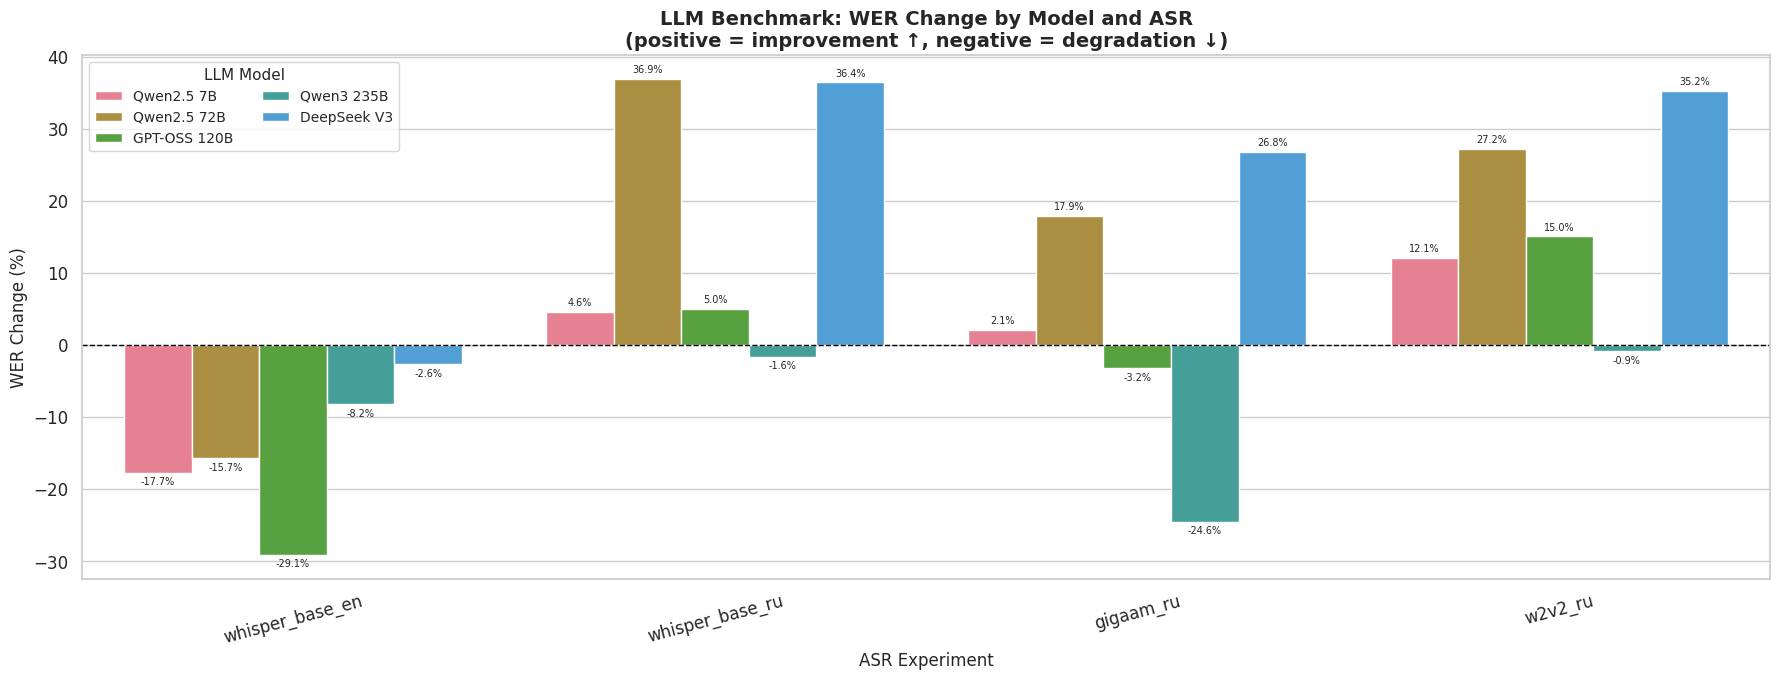

In [20]:
# Build viz DataFrame
viz_rows = []
for key, df in all_results.items():
    if len(df) == 0:
        continue
    llm_name, asr_key = key.split('__')
    bl = df['wer_baseline'].mean()
    cr = df['wer_corrected'].mean()
    viz_rows.append({
        'LLM': llm_name,
        'ASR': asr_key,
        'WER Change (%)': (bl - cr) / bl * 100,
        'Baseline WER': bl,
        'Corrected WER': cr,
        'Improved (%)': df['wer_improved'].mean() * 100,
        'Degraded (%)': df['wer_degraded'].mean() * 100,
    })
viz_df = pd.DataFrame(viz_rows)

# --- Plot 1: WER Change ---
fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(
    data=viz_df, x='ASR', y='WER Change (%)',
    hue='LLM', ax=ax, edgecolor='white',
)
ax.axhline(y=0, color='black', linewidth=1, ls='--')
ax.set_title(
    'LLM Benchmark: WER Change by Model and ASR\n'
    '(positive = improvement ↑, negative = degradation ↓)',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('ASR Experiment', fontsize=12)
ax.set_ylabel('WER Change (%)', fontsize=12)
ax.legend(
    title='LLM Model', fontsize=10,
    title_fontsize=11, loc='best', ncol=2,
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container, fmt='%.1f%%', fontsize=7,
        padding=3,
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 9.2 Corrected WER: абсолютные значения

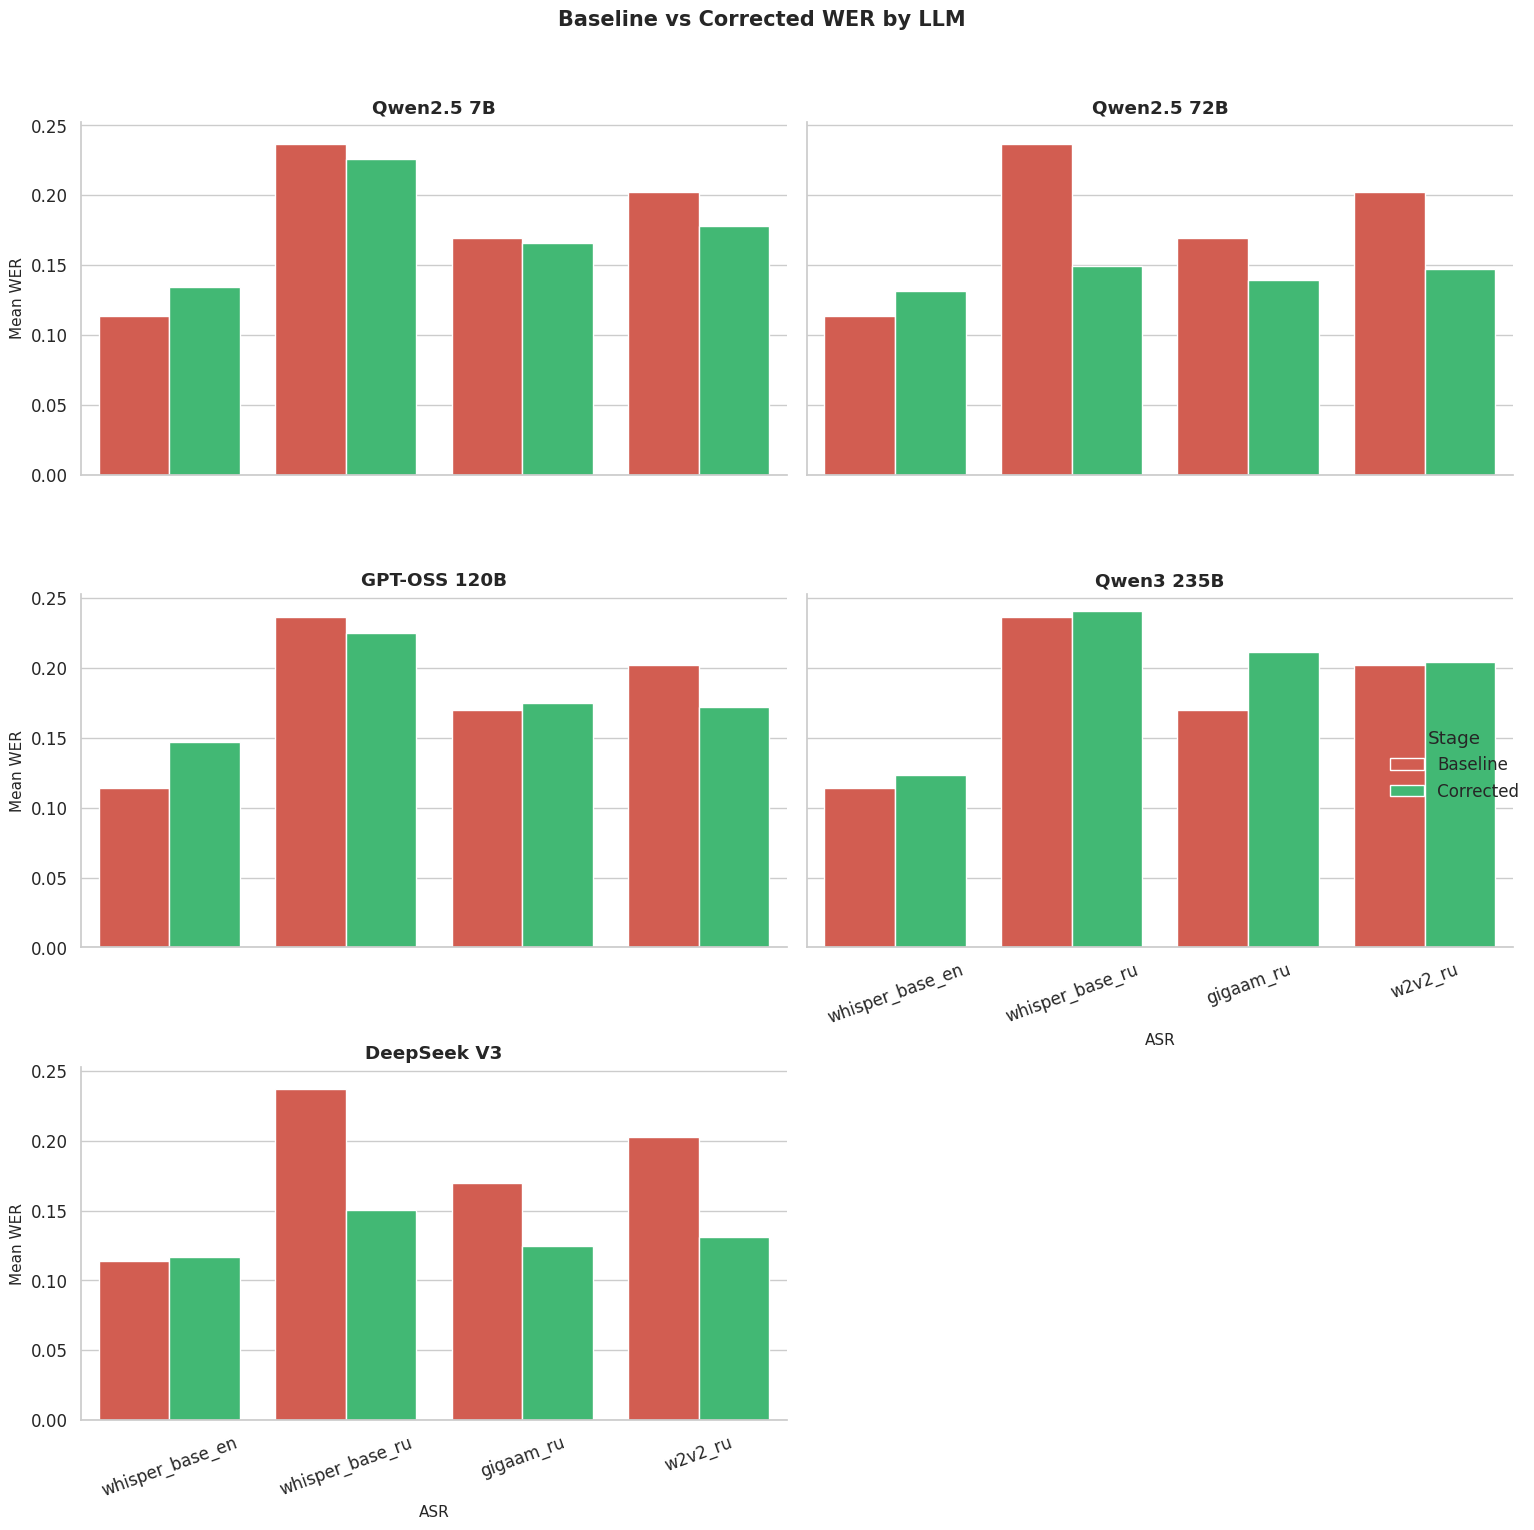

In [21]:
# Melt for paired comparison
melt_rows = []
for key, df in all_results.items():
    if len(df) == 0:
        continue
    llm, asr = key.split('__')
    melt_rows.append({
        'LLM': llm, 'ASR': asr,
        'Stage': 'Baseline',
        'WER': df['wer_baseline'].mean(),
    })
    melt_rows.append({
        'LLM': llm, 'ASR': asr,
        'Stage': 'Corrected',
        'WER': df['wer_corrected'].mean(),
    })
melt_df = pd.DataFrame(melt_rows)

g = sns.catplot(
    data=melt_df, x='ASR', y='WER',
    hue='Stage', col='LLM', kind='bar',
    col_wrap=2, height=5, aspect=1.4,
    palette=['#e74c3c', '#2ecc71'],
    edgecolor='white',
)
g.set_titles(
    '{col_name}', fontsize=13, fontweight='bold',
)
g.set_axis_labels('ASR', 'Mean WER', fontsize=11)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=20)

g.fig.suptitle(
    'Baseline vs Corrected WER by LLM',
    fontsize=15, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

### 9.3 Improved vs Degraded

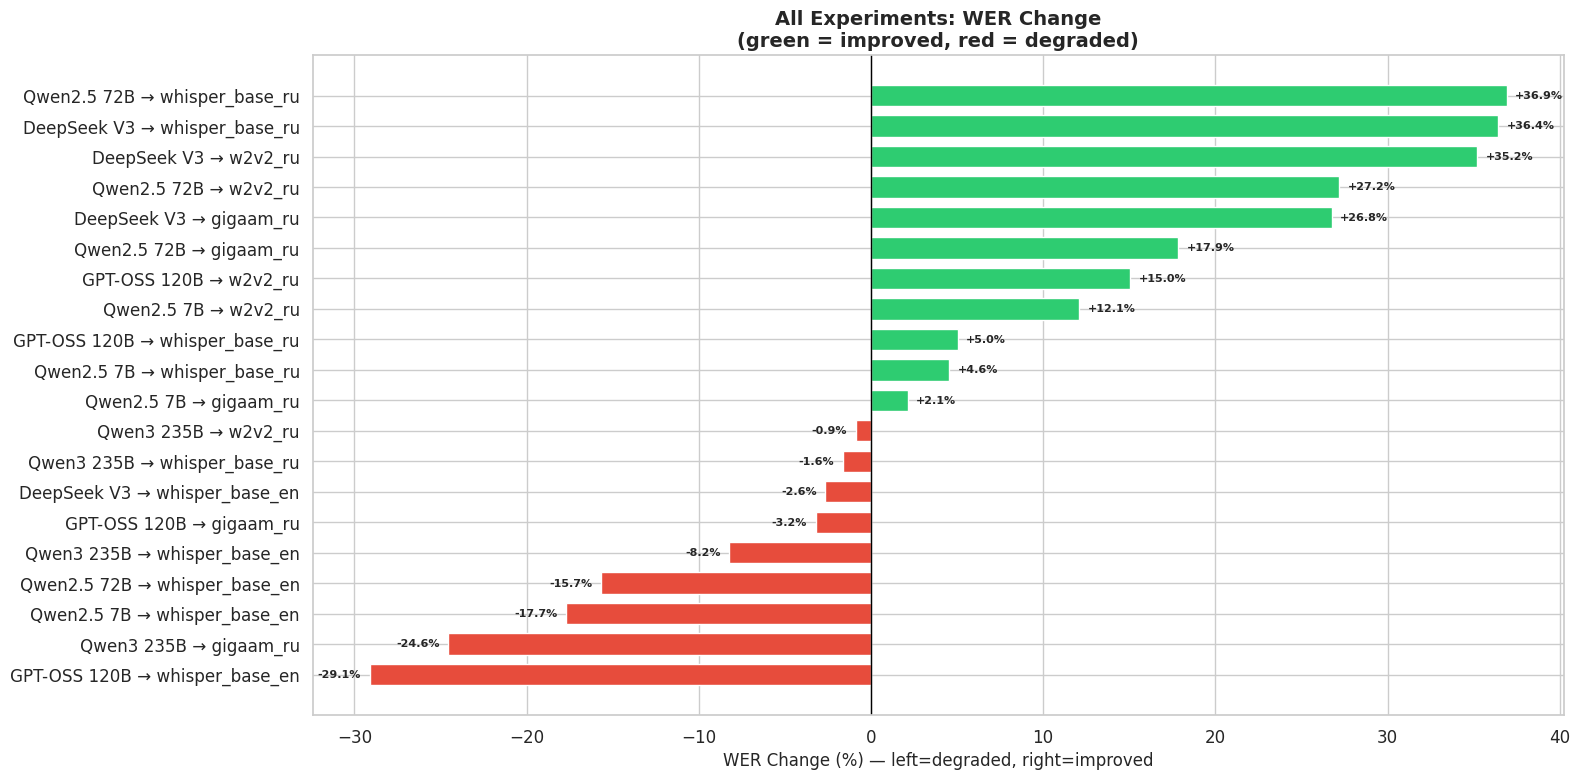

In [22]:
fig, ax = plt.subplots(figsize=(16, 8))

# Create labels
viz_df['Label'] = (
    viz_df['LLM'] + ' -> ' + viz_df['ASR']
)
viz_sorted = viz_df.sort_values('WER Change (%)')

colors = [
    '#2ecc71' if v > 0 else '#e74c3c'
    for v in viz_sorted['WER Change (%)']
]

ax.barh(
    viz_sorted['Label'],
    viz_sorted['WER Change (%)'],
    color=colors, edgecolor='white',
    height=0.7,
)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel(
    'WER Change (%) — left=degraded, right=improved',
    fontsize=12,
)
ax.set_title(
    'All Experiments: WER Change\n'
    '(green = improved, red = degraded)',
    fontsize=14, fontweight='bold',
)

# Value labels
for i, (val, label) in enumerate(
    zip(viz_sorted['WER Change (%)'], viz_sorted['Label'])
):
    ax.text(
        val + (0.5 if val >= 0 else -0.5), i,
        f'{val:+.1f}%',
        ha='left' if val >= 0 else 'right',
        va='center', fontsize=8, fontweight='bold',
    )

plt.tight_layout()
plt.show()

### 9.4 Heatmap: WER Change

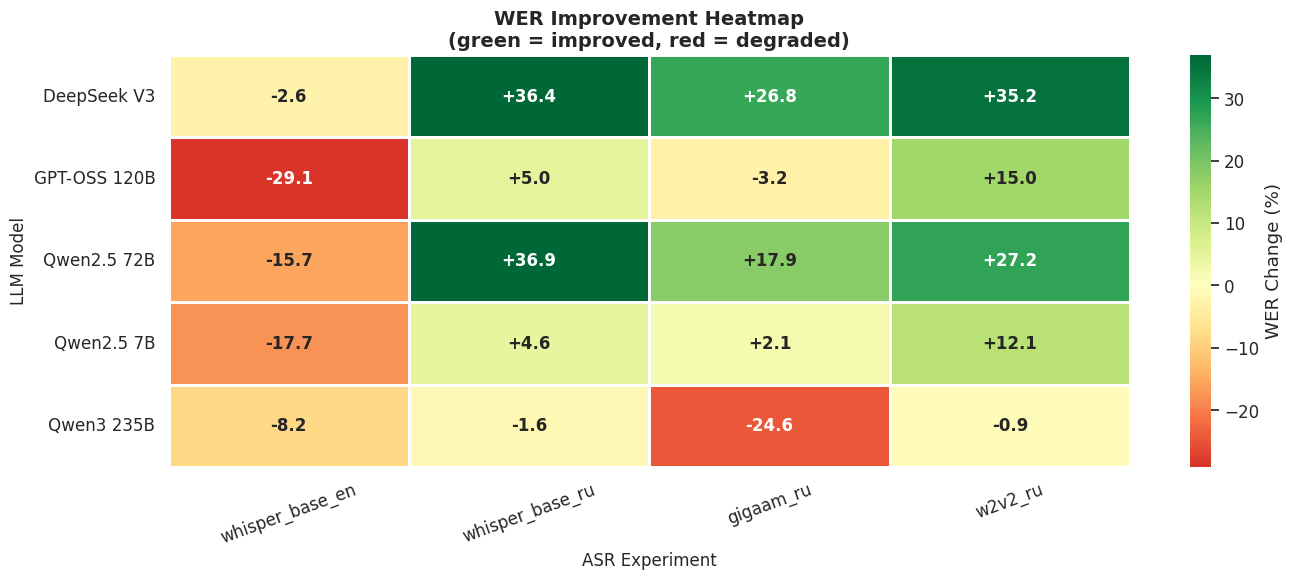

In [23]:
# Pivot for heatmap
heatmap_df = viz_df.pivot(
    index='LLM', columns='ASR',
    values='WER Change (%)',
)

# Reorder columns
col_order = [
    c for c in [
        'whisper_base_en', 'whisper_large_en',
        'whisper_base_ru', 'whisper_large_ru',
        'gigaam_ru', 'w2v2_ru',
    ] if c in heatmap_df.columns
]
heatmap_df = heatmap_df[col_order]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_df, annot=True, fmt='+.1f',
    cmap='RdYlGn', center=0, linewidths=2,
    linecolor='white', ax=ax,
    annot_kws={'fontsize': 12, 'fontweight': 'bold'},
    cbar_kws={'label': 'WER Change (%)'},
)
ax.set_title(
    'WER Improvement Heatmap\n'
    '(green = improved, red = degraded)',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('ASR Experiment', fontsize=12)
ax.set_ylabel('LLM Model', fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 9.5 ASR Baseline WER Comparison

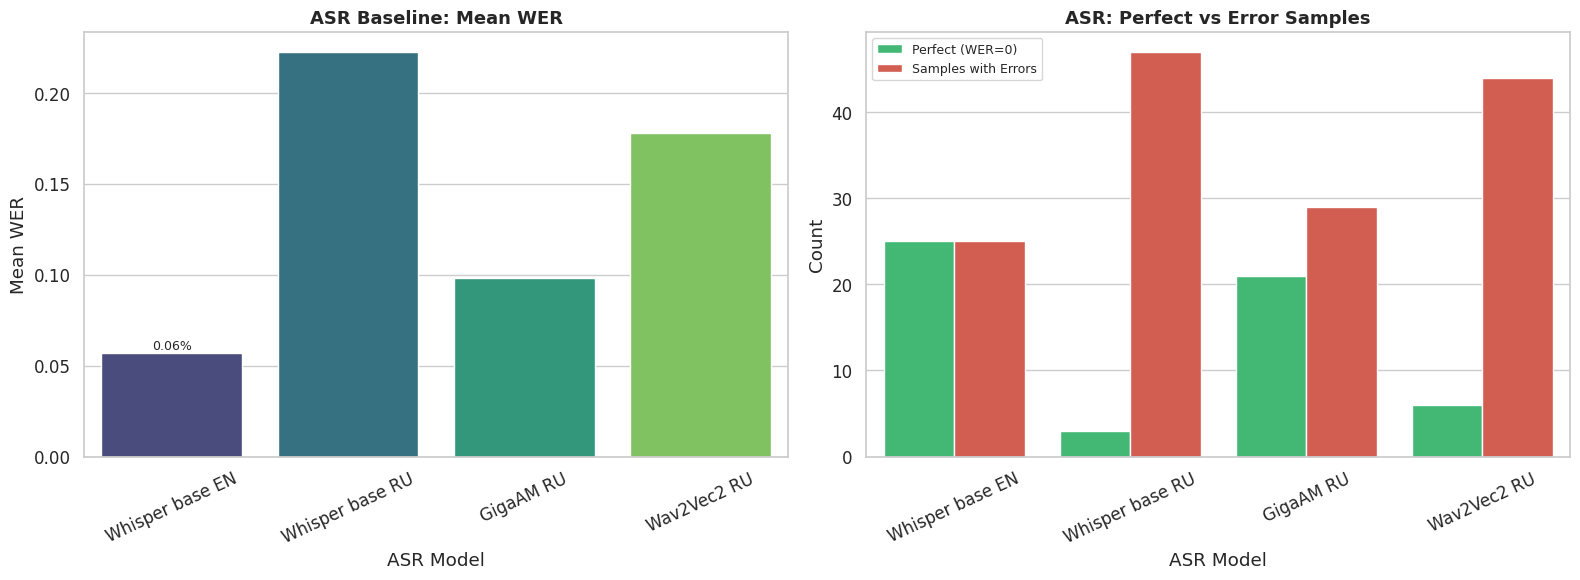

In [24]:
# ASR baseline comparison
bl_data = []
for name, df in all_baselines.items():
    bl_data.append({
        'ASR Model': name,
        'Mean WER': df['wer'].mean(),
        'Mean CER': df['cer'].mean(),
        'Samples with Errors': (df['wer'] > 0).sum(),
        'Perfect (WER=0)': (df['wer'] == 0).sum(),
    })
bl_df = pd.DataFrame(bl_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# WER comparison
sns.barplot(
    data=bl_df, x='ASR Model', y='Mean WER',
    ax=axes[0], palette='viridis', edgecolor='white',
)
axes[0].set_title(
    'ASR Baseline: Mean WER', fontsize=13,
    fontweight='bold',
)
axes[0].bar_label(
    axes[0].containers[0], fmt='%.2f%%',
    fontsize=9,
)
axes[0].tick_params(axis='x', rotation=25)

# Perfect vs Error samples
bl_melt = bl_df.melt(
    id_vars='ASR Model',
    value_vars=['Perfect (WER=0)', 'Samples with Errors'],
    var_name='Type', value_name='Count',
)
sns.barplot(
    data=bl_melt, x='ASR Model', y='Count',
    hue='Type', ax=axes[1],
    palette=['#2ecc71', '#e74c3c'],
    edgecolor='white',
)
axes[1].set_title(
    'ASR: Perfect vs Error Samples',
    fontsize=13, fontweight='bold',
)
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 9.6 Correlation: Baseline WER vs LLM Effectiveness

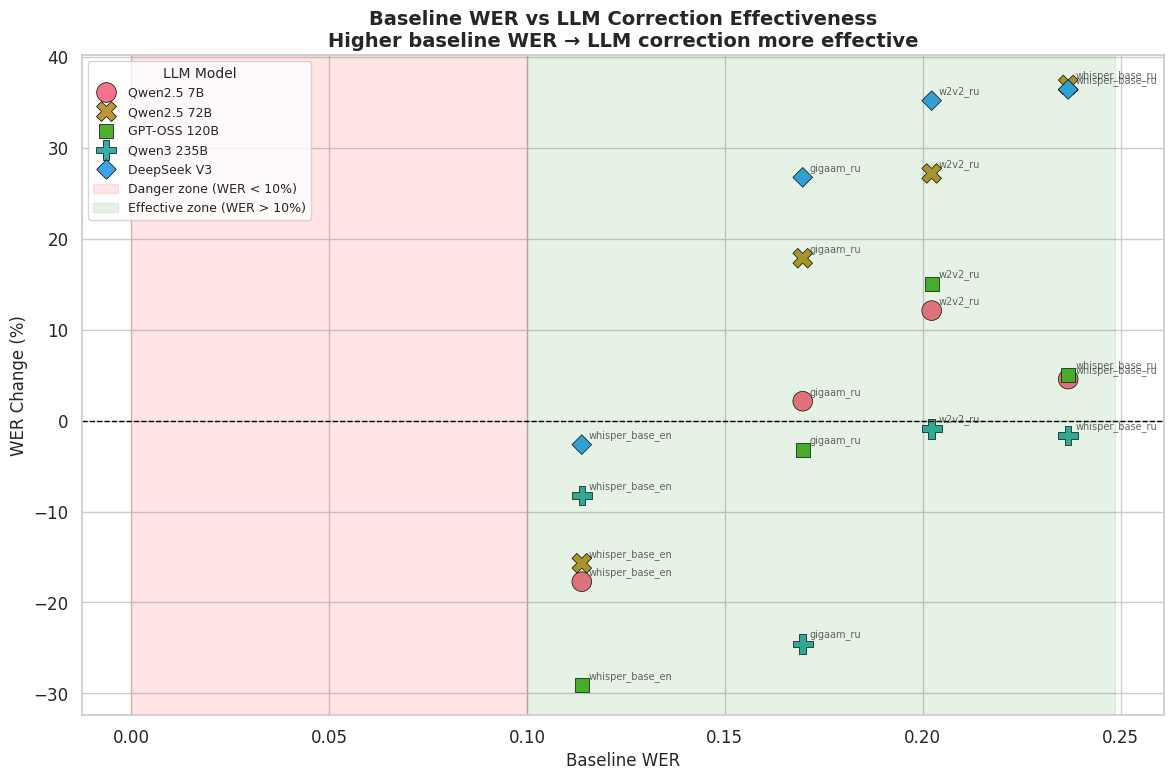

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=viz_df, x='Baseline WER',
    y='WER Change (%)', hue='LLM',
    style='LLM', s=200, ax=ax,
    edgecolor='black', linewidth=0.5,
)

# Add ASR labels
for _, row in viz_df.iterrows():
    ax.annotate(
        row['ASR'], (row['Baseline WER'],
        row['WER Change (%)']),
        fontsize=7, alpha=0.7,
        xytext=(5, 5),
        textcoords='offset points',
    )

ax.axhline(y=0, color='black', ls='--', lw=1)

# Threshold zone
ax.axvspan(
    0, 0.10, alpha=0.1, color='red',
    label='Danger zone (WER < 10%)',
)
ax.axvspan(
    0.10, ax.get_xlim()[1], alpha=0.1,
    color='green',
    label='Effective zone (WER > 10%)',
)

ax.set_title(
    'Baseline WER vs LLM Correction Effectiveness\n'
    'Higher baseline WER -> LLM correction more effective',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('Baseline WER', fontsize=12)
ax.set_ylabel('WER Change (%)', fontsize=12)
ax.legend(
    fontsize=9, loc='best',
    title='LLM Model', title_fontsize=10,
)
plt.tight_layout()
plt.show()

### 9.7 LLM Performance Radar

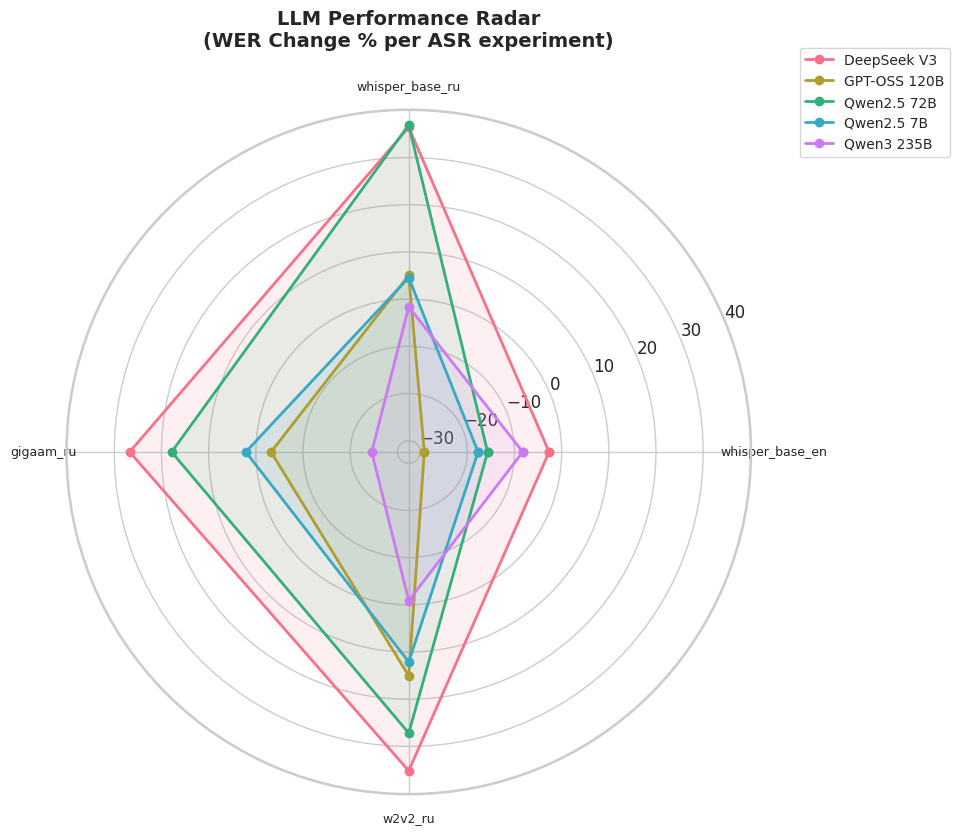

In [26]:
from math import pi

categories = list(heatmap_df.columns)
n_cats = len(categories)
angles = [
    n / float(n_cats) * 2 * pi
    for n in range(n_cats)
]
angles += angles[:1]  # close

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True),
)

colors = sns.color_palette('husl', len(heatmap_df))

for i, (llm, row) in enumerate(heatmap_df.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(
        angles, values, 'o-',
        linewidth=2, label=llm,
        color=colors[i],
    )
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title(
    'LLM Performance Radar\n'
    '(WER Change % per ASR experiment)',
    fontsize=14, fontweight='bold', y=1.08,
)
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1),
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 10. Выводы

### Сводная таблица результатов (WER Change %)

| LLM | Whisper EN | Whisper RU | GigaAM RU | W2V2 RU |
|-----|-----------|-----------|-----------|---------|
| Qwen2.5 7B | -17.7%  | +4.6%  | +2.1%  | +12.1%  |
| Qwen2.5 72B | -15.7%  | +36.9%  | +17.9%  | +27.2%  |
| GPT-OSS 120B | -29.1%  | +5.0% | -3.2%  | +15.0%  |
| Qwen3 235B | -8.2%  | -1.6%  | -24.6%  | -0.9%  |
| DeepSeek V3 | -2.6%  | +36.4%  | +26.8%  | +35.2%  |

### 1. Влияет ли размер LLM на качество коррекции?

Да, но не линейно и не монотонно. Переход с 7B на 72B (Qwen2.5) даёт резкий прирост: Whisper RU +4.6% → +36.9%, W2V2 +12.1% → +27.2%. Однако дальнейшее увеличение размера не гарантирует улучшения — Qwen3 235B (MoE) ухудшает почти все эксперименты, а GPT-OSS 120B (MoE) значительно слабее Qwen2.5 72B (dense). Ключевой фактор — не размер, а архитектура и качество обучения. Dense-модели (Qwen2.5 72B) стабильнее MoE (Qwen3 235B, GPT-OSS 120B) для задачи ASR-коррекции.

### 2. Какая LLM лучше справляется с русским языком?

**DeepSeek V3 (685B MoE)** — лидер по русскому языку: Whisper RU +36.4%, GigaAM +26.8%, W2V2 +35.2%. Стабильно улучшает все три русскоязычных ASR. **Qwen2.5 72B** — сильный второй: Whisper RU +36.9% (даже чуть выше DeepSeek), GigaAM +17.9%, W2V2 +27.2%. Обе модели обучены на мультиязычных данных с большой долей CJK и русского.

**GPT-OSS 120B** (OpenAI) слабо работает с русским (+5.0% на Whisper RU, -3.2% на GigaAM). Это объяснимо: модель обучена преимущественно на английском тексте с фокусом на STEM и код.

### 3. Корреляция baseline WER и эффективности коррекции

Чёткая закономерность подтверждена на 4 ASR × 5 LLM = 20 экспериментах:

- **Whisper EN** (baseline WER 5.69%): все 5 моделей ухудшают — мало ошибок для исправления, LLM вносит новые.
- **Whisper RU** (baseline WER 22.26%): 4 из 5 моделей улучшают (до +36.9%).
- **W2V2 RU** (baseline WER 17.80%): 3 из 5 моделей улучшают (до +35.2%).
- **GigaAM RU** (baseline WER 9.84%): только 3 модели улучшают, эффект слабее.

Эмпирический порог: LLM-коррекция стабильно помогает при baseline WER > ~15%. При WER < 10% результаты нестабильны и зависят от конкретной LLM. Это прямо мотивирует confidence-aware подход — корректировать только фрагменты с низким confidence.

### 4. Какая ASR даёт ошибки, наиболее поддающиеся LLM-коррекции?

**Wav2Vec2 XLS-R 1B** (WER 17.80%) — наиболее благодарный для коррекции: DeepSeek V3 снижает WER на 35.2%, Qwen2.5 72B на 27.2%. Wav2Vec2 — CTC-модель без языковой модели, её ошибки преимущественно лингвистические (неправильные слова, отсутствие контекста), что LLM исправляет хорошо.

**Whisper RU** (WER 22.26%) — тоже хорошо поддаётся коррекции (+36.9% с Qwen2.5 72B). Whisper на русском допускает ошибки из-за мультиязычного декодера.

**GigaAM** (WER 9.84%) — труднее корректировать. Модель уже достаточно точная, и многие «ошибки» — это пограничные случаи, которые LLM не может улучшить без аудио.

### 5. Сравнение семейств: Alibaba vs OpenAI vs DeepSeek

**Alibaba (Qwen):** два поколения с разным результатом. Qwen2.5 72B — лучший баланс качества и стабильности. Qwen3 235B (reasoning MoE) — парадоксально хуже, вероятно из-за reasoning-токенов, которые «отвлекают» модель от простой задачи коррекции.

**OpenAI (GPT-OSS 120B):** слабый на русском, умеренный на английском. Обучен на англоцентричных данных (STEM, код). Для ASR-коррекции не оптимален.

**DeepSeek (V3 685B MoE):** лучшая модель бенчмарка. Стабильно улучшает все русскоязычные ASR, минимально вредит английскому (-2.6%). Мощная мультиязычная модель с хорошим балансом.

### 6. Неожиданные наблюдения

**Qwen3 235B — худшая модель бенчмарка**, несмотря на 235B параметров. Ухудшает GigaAM на -24.6%. Вероятная причина — reasoning chain: модель генерирует внутренние рассуждения, которые могут «загрязнять» выходной текст или приводить к перефразированию.

**GPT-OSS 120B на английском (-29.1%)** — хуже чем Qwen2.5 7B (-17.7%). Первая open-weight модель OpenAI явно не оптимизирована для задачи text-to-text коррекции.

**Qwen2.5 7B** — при всего 7B параметрах улучшает 3 из 4 экспериментов. Для задач с ограниченными ресурсами — разумный выбор.

### Итоговые рекомендации

1. **Лучшая модель для русского языка:** DeepSeek V3 или Qwen2.5 72B
2. **Не применять LLM-коррекцию при baseline WER < 10%** без confidence-фильтрации
3. **Dense-модели стабильнее MoE** для задачи ASR-коррекции
4. **Reasoning-модели (Qwen3) не подходят** для простой текстовой коррекции
5. **Следующий шаг:** confidence-aware подход — пороговая фильтрация перед коррекцией

## 11. Сохранение результатов

In [ ]:
# Save summary
summary.to_csv('benchmark_summary.csv', index=False)

# Save detailed results
for key, df in all_results.items():
    if len(df) > 0:
        fname = f'benchmark_{key}.csv'
        df.to_csv(fname, index=False)

print('Results saved')

In [ ]:
from google.colab import files

files.download('benchmark_summary.csv')
for key in all_results:
    fname = f'benchmark_{key}.csv'
    if os.path.exists(fname):
        files.download(fname)